# Pre-Processing


1) cut out the first and last 1.5s from the recordings (they’re influenced by the touching of the screen to hit the record/end recording button);

2) Pass band filter to keep only the interesting frequencies;

3) Division of the recording into set windows;

4) Delete not significative windows (check delta between all consecutive measurements + deceleration in past windows) (create one dataset keeping not significative windows and one Fourier transform;

5) Calcolare mean, variance, standard deviation, min, max, difference between min and max, …


In [2]:
# Cut-Out script

import os
import pandas as pd

RAW_REC_DIR = "../raw_data"
PRE_PROCESSING_DIR = "../preprocessing"
CUT_OUT_DIR = PRE_PROCESSING_DIR + "/cut_out_start_end"
SENSOR_FILES = ["Accelerometer.csv", "Gyroscope.csv", "Gravity.csv"]

# Read recordings in each folder and cut the first and last 1.5 seconds meausurements

for recording in os.listdir(RAW_REC_DIR):

    #print(f"Processing {recording}...")
    recording_path = os.path.join(RAW_REC_DIR, recording)
    cutout_recording_path = os.path.join(CUT_OUT_DIR, recording)

    if not os.path.exists(cutout_recording_path):
        os.makedirs(cutout_recording_path)

    for measurement_type in os.listdir(recording_path):

        if measurement_type in SENSOR_FILES:

            raw_file_path = os.path.join(recording_path, measurement_type)
            cutout_file_path = os.path.join(cutout_recording_path, measurement_type)

            # Read the CSV file with pandas

            # pd.read_csv() loads the CSV into a Pandas DataFrame:
            # a tabular structure (map or dictionary) where each column contains an array of values
            # associated with a common row index.
            data = pd.read_csv(raw_file_path)

            # Cut the first and last 1.5 seconds of measurements
            sampling_rate = 100  # Assuming a sampling rate of 100 Hz
            cut_samples = int(1.5 * sampling_rate)

            # Ensure we have enough data to cut
            if len(data) > 2 * cut_samples:
                # iloc selects rows by integer position, excluding the first and last cut_samples rows.
                cut_data = data.iloc[cut_samples:-cut_samples]
                #index=False tells pandas not to save the DataFrame’s row index as an extra column in the CSV file.
                cut_data.to_csv(cutout_file_path, index=False)
                print(f"Processed {recording}: Cut first and last 1.5 seconds.")
            else:
                print(f"Skipping {recording}: Not enough data to cut.")



Processed bumpy_con_tante_buche-2026-09-21_13-24-26: Cut first and last 1.5 seconds.
Processed bumpy_con_tante_buche-2026-09-21_13-24-26: Cut first and last 1.5 seconds.
Processed bumpy_con_tante_buche-2026-09-21_13-24-26: Cut first and last 1.5 seconds.
Processed bumpy_con_una_grande_curva_alla_fine-2026-09-21_13-47-25: Cut first and last 1.5 seconds.
Processed bumpy_con_una_grande_curva_alla_fine-2026-09-21_13-47-25: Cut first and last 1.5 seconds.
Processed bumpy_con_una_grande_curva_alla_fine-2026-09-21_13-47-25: Cut first and last 1.5 seconds.
Processed bumpy_stadio: Cut first and last 1.5 seconds.
Processed bumpy_stadio: Cut first and last 1.5 seconds.
Processed bumpy_stadio: Cut first and last 1.5 seconds.
Processed bumpy_stazione: Cut first and last 1.5 seconds.
Processed bumpy_stazione: Cut first and last 1.5 seconds.
Processed bumpy_stazione: Cut first and last 1.5 seconds.
Processed bumpy_stradabumpy_con_rialzi_e_buche-2026-09-21_13-44-51: Cut first and last 1.5 seconds.
Pro

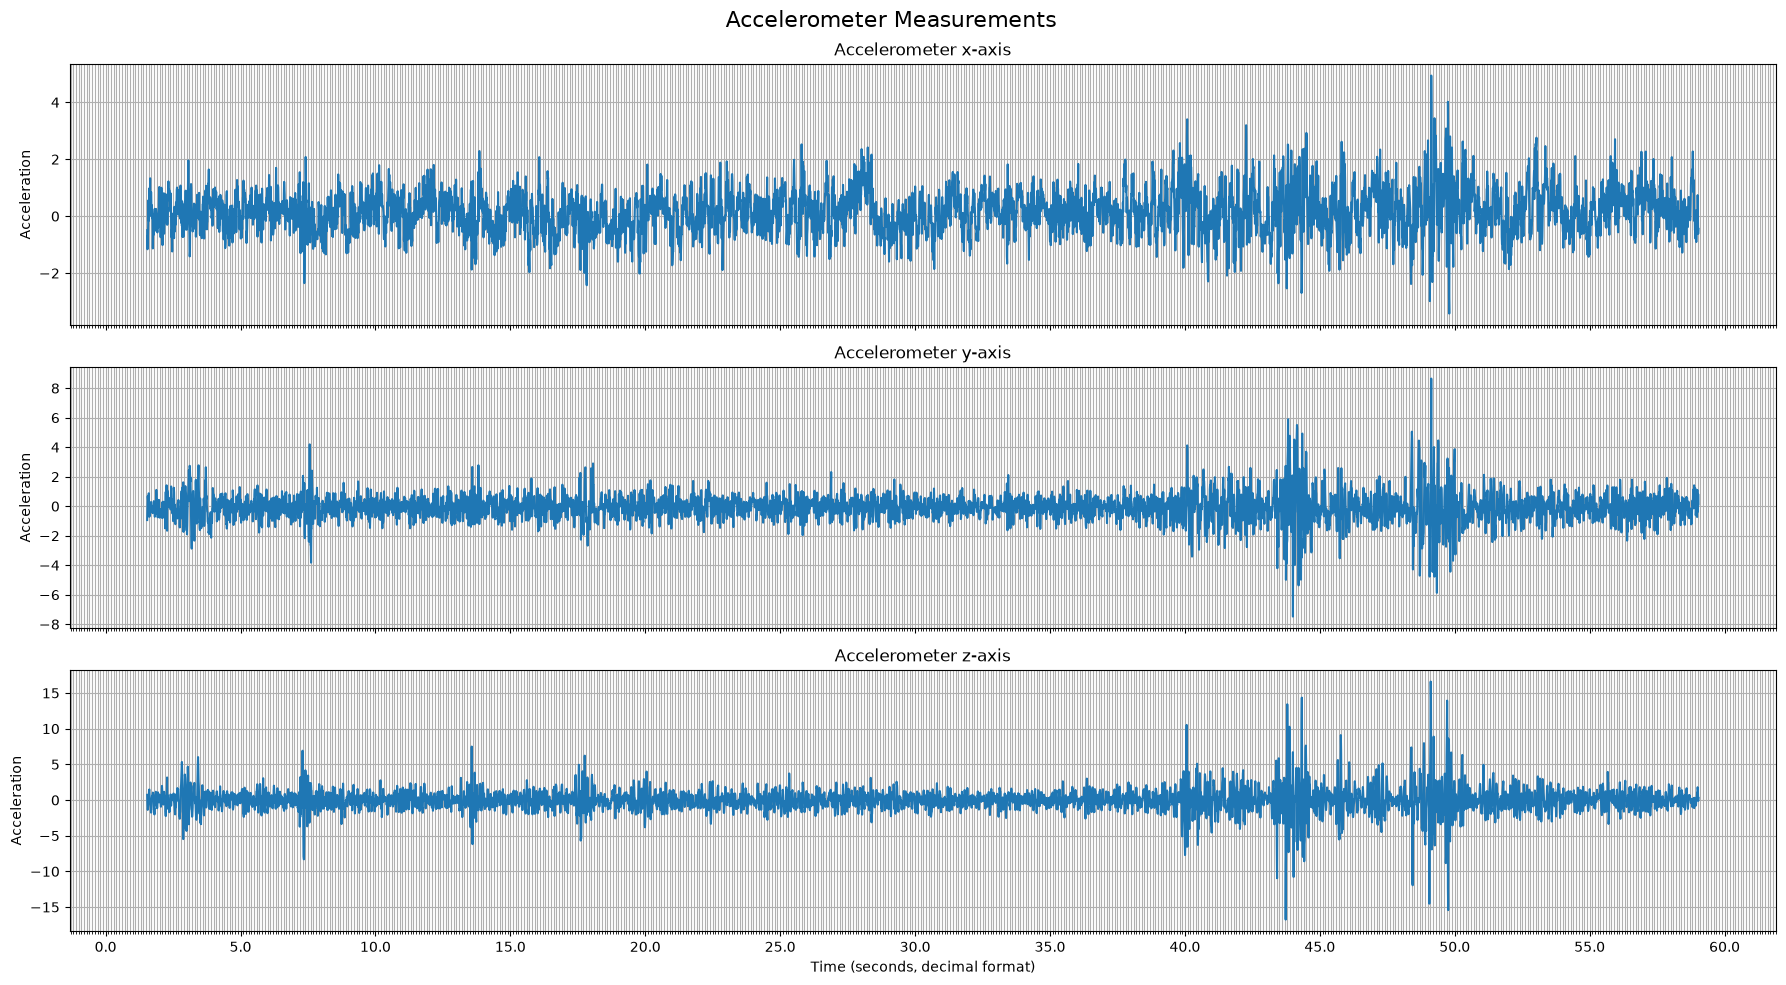

In [3]:
# Plotting script for visualizing the effect of preprocessing steps

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter



# Load one accelerometer recording into a DataFrame
data = pd.read_csv(CUT_OUT_DIR + "/bumpy_stadio/Accelerometer.csv")

# Create one plot for each accelerometer axis
fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

for axis, axis_name in zip(axes, ["x", "y", "z"]):
    axis.plot(data["seconds_elapsed"], data[axis_name])
    axis.set_title(f"Accelerometer {axis_name}-axis")
    axis.set_ylabel("Acceleration")
    axis.grid(True, which="both")
    axis.xaxis.set_major_locator(MultipleLocator(5.0))
    axis.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    axis.xaxis.set_minor_locator(MultipleLocator(0.1))

axes[-1].set_xlabel("Time (seconds, decimal format)")
fig.suptitle("Accelerometer Measurements", fontsize=16)
fig.tight_layout()
plt.show()


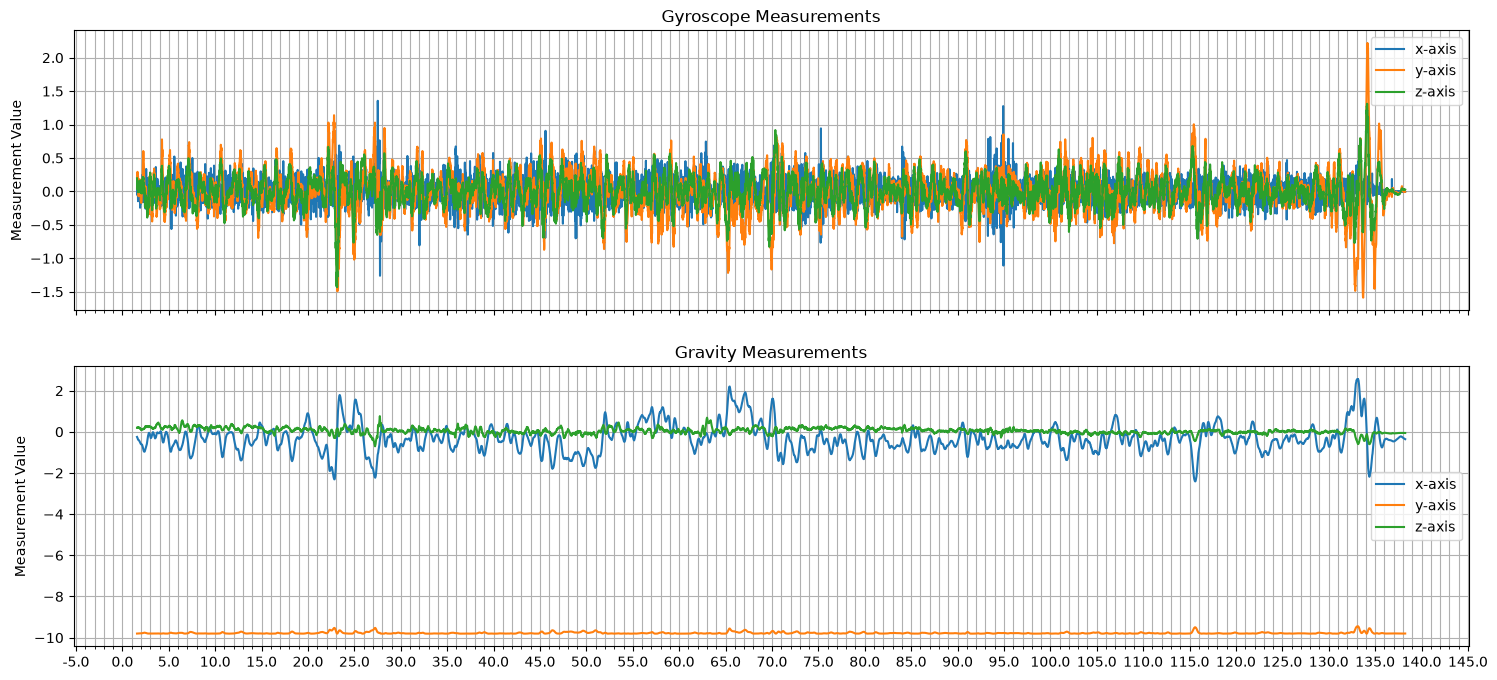

In [4]:
# plot the giroscope and gravity measurements

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
for i, measurement_type in enumerate(["Gyroscope", "Gravity"]):
    data = pd.read_csv(CUT_OUT_DIR + f"/bumpy_con_tante_buche-2026-09-21_13-24-26/{measurement_type}.csv")
    for axis_name in ["x", "y", "z"]:
        axes[i].plot(data["seconds_elapsed"], data[axis_name], label=f"{axis_name}-axis")
    axes[i].set_title(f"{measurement_type} Measurements")
    axes[i].set_ylabel("Measurement Value")
    axes[i].grid(True, which="both")
    axes[i].xaxis.set_major_locator(MultipleLocator(5.0))
    axes[i].xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    axes[i].xaxis.set_minor_locator(MultipleLocator(1.0))
    axes[i].legend()



# Stationary segment removal

We want to remove the stationary segment because they do not influence the final decision of the class of the road.
For instance, if we stop before a traffic light, those 5/10 seconds will be useless for our classification of the quality of the roads.

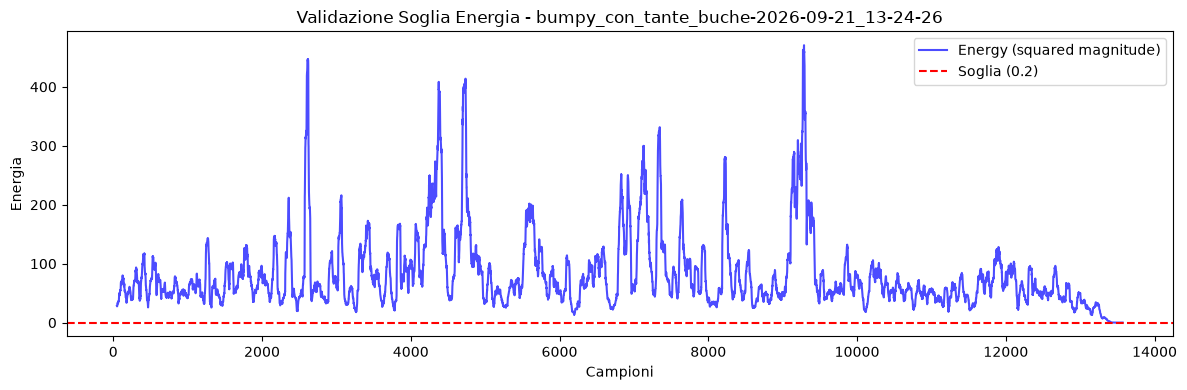

In [9]:
# stationary segment removal script
import pandas as pd
import os
import matplotlib.pyplot as plt

OUTPUT_DIR = "../preprocessing/cut_out_remove_stationary" # Dove vuoi salvare i nuovi dati

VALIDATE_PLOT = True  # Set to True to visualize the energy and threshold for validation

#for each recording, remove the stationary segments based on the accelerometer data
for recording in os.listdir(CUT_OUT_DIR):
    accelerometer_file_path = os.path.join(CUT_OUT_DIR, recording, "Accelerometer.csv")
    accelerometer_data = pd.read_csv(accelerometer_file_path)
    gyroscope_file_path = os.path.join(CUT_OUT_DIR, recording, "Gyroscope.csv")
    gyroscope_data = pd.read_csv(gyroscope_file_path)
    gravity_file_path = os.path.join(CUT_OUT_DIR, recording, "Gravity.csv")
    gravity_data = pd.read_csv(gravity_file_path)

    MAX_ALLOWED_DIFF = 5  # Allow up to 5 samples of difference
    
    lengths = {
        'Acc': len(accelerometer_data),
        'Gyro': len(gyroscope_data),
        'Grav': len(gravity_data)
    }
    
    max_len = max(lengths.values())
    min_len = min(lengths.values())
    
    # Raise error only if the difference is actually problematic
    if (max_len - min_len) > MAX_ALLOWED_DIFF:
        raise ValueError(f"CRITICAL ERROR in {recording}: Sensors are out of sync! "
                         f"Difference is {max_len - min_len} (max allowed: {MAX_ALLOWED_DIFF}). "
                         f"Lengths: {lengths}")
    
    # Truncate all DataFrames to the shortest length to ensure perfect alignment (by creating copies of the DataFrames)
    # This prevents Pandas boolean indexing crashes if one sensor has 1-2 extra rows.
    acc_work= accelerometer_data.iloc[:min_len]
    gyr_work = gyroscope_data.iloc[:min_len]
    grav_work = gravity_data.iloc[:min_len]

    # Calculate the magnitude of the accelerometer data
    magnitude = (acc_work["x"]**2 + acc_work["y"]**2 + acc_work["z"]**2)**0.5
    energy_threshold = 0.20  # Define a threshold for stationary segments

    # Calculate the energy of the accelerometer data using rolling window mean of the squared magnitude
    energy = (magnitude**2).rolling(window=50).mean()  # Adjust window size as needed

    # Plot the energy and threshold for validation
    if VALIDATE_PLOT:
        plt.figure(figsize=(12, 4))
        plt.plot(energy, label='Energy (squared magnitude)', color='blue', alpha=0.7)
        plt.axhline(y=energy_threshold, color='red', linestyle='--', label=f'Soglia ({energy_threshold})')
        plt.title(f"Validazione Soglia Energia - {recording}")
        plt.xlabel("Campioni")
        plt.ylabel("Energia")
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        # IMPORTANTE: Dopo aver visto il primo grafico e confermato la soglia, 
        # cambia VALIDATE_PLOT = False qui sopra per non bloccare il loop sui file successivi.
        input("Premi Invio per continuare con gli altri file...")
        VALIDATE_PLOT = False

    # Identify stationary segments where energy is below the threshold
    stationary_segments = energy < energy_threshold

    # require that stationary segments are at least 2 seconds long (200 samples at 100 Hz)
    min_stationary_length = 200

    # 1. assign a unique ID to each run of consecutive True values in stationary_segments
    run_ids = (stationary_segments != stationary_segments.shift()).cumsum()
    
    # 2. compute the length of each run of consecutive True values
    run_lengths = stationary_segments.groupby(run_ids).transform('size')
    
    # 3. keep only the runs of consecutive True values that are at least min_stationary_length long
    stationary_segments = stationary_segments & (run_lengths >= min_stationary_length)

    # Remove stationary segments from the all data
    filtered_accelerometer_data = acc_work[~stationary_segments]
    filtered_gyroscope_data = gyr_work[~stationary_segments]
    filtered_gravity_data = grav_work[~stationary_segments]
    
    # create a new folder in preprocessing called cut_out_remove_stationary to store the filtered accelerometer data
    new_folder_path = os.path.join(OUTPUT_DIR, recording)
    os.makedirs(new_folder_path, exist_ok=True)

    # Save the filtered data
    filtered_accelerometer_data.to_csv(os.path.join(new_folder_path, "Accelerometer.csv"), index=False)
    filtered_gyroscope_data.to_csv(os.path.join(new_folder_path, "Gyroscope.csv"), index=False)
    filtered_gravity_data.to_csv(os.path.join(new_folder_path, "Gravity.csv"), index=False)

# Check to see if any part was removed

By plotting the data before and after the stationary parts removal, we can see the differences

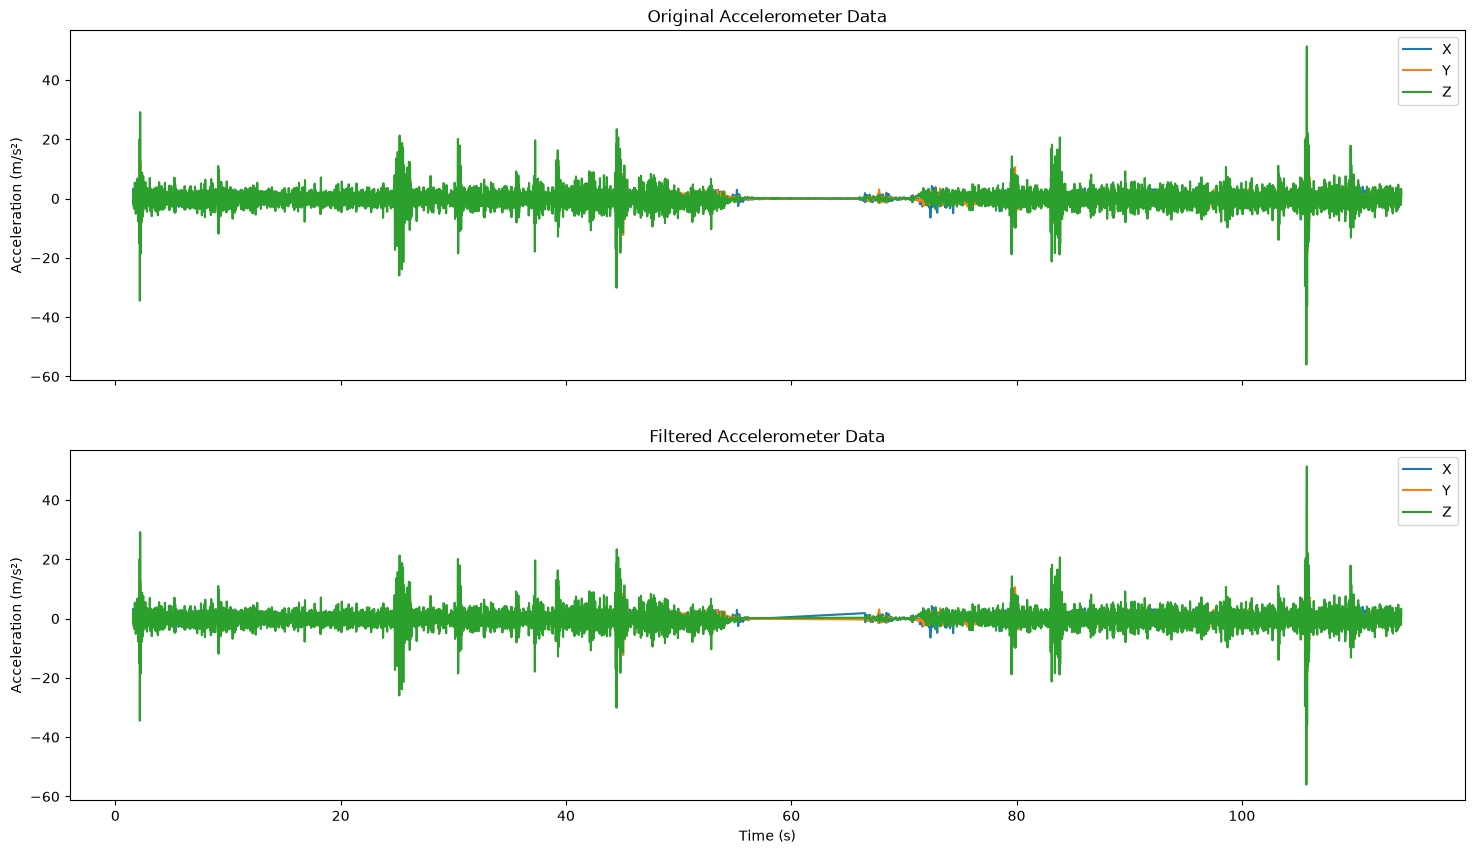

In [13]:
# plot the data pre and post stationary removal for validation
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the original and filtered accelerometer data for a specific recording
recording = "smooth_con_fermata_2-2026-09-23_14-35-33"  # Replace with the desired recording name
original_accelerometer_data = pd.read_csv(os.path.join(CUT_OUT_DIR, recording, "Accelerometer.csv"))
filtered_accelerometer_data = pd.read_csv(os.path.join(OUTPUT_DIR, recording, "Accelerometer.csv"))

# 2. Create a figure with two subplots: one for the original data and one for the filtered data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# 3. Plot the original accelerometer data
ax1.plot(original_accelerometer_data['seconds_elapsed'], original_accelerometer_data['x'], label='X')
ax1.plot(original_accelerometer_data['seconds_elapsed'], original_accelerometer_data['y'], label='Y')
ax1.plot(original_accelerometer_data['seconds_elapsed'], original_accelerometer_data['z'], label='Z')
ax1.set_title('Original Accelerometer Data')
ax1.set_ylabel('Acceleration (m/s²)')
ax1.legend()

# 4. Plot the filtered accelerometer data
ax2.plot(filtered_accelerometer_data['seconds_elapsed'], filtered_accelerometer_data['x'], label='X')
ax2.plot(filtered_accelerometer_data['seconds_elapsed'], filtered_accelerometer_data['y'], label='Y')
ax2.plot(filtered_accelerometer_data['seconds_elapsed'], filtered_accelerometer_data['z'], label='Z')
ax2.set_title('Filtered Accelerometer Data')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Acceleration (m/s²)')
ax2.legend()




As we can see the two plots are exactly the same, and it is what we were expecting since in this registration we always were in movement, but there can be some cases in the future where or from other registrations where we had to stop, due to circumstances, and this procedure cut out the parts where we stayed fixed

# Orientation alignment

The physical orientation of the smartphone varies between different bike rides, even by a little. Because of this, a vertical event like a pothole might be recorded primarily on the X-axis in one ride, and on the Z-axis in another. 

To solve this, we use the `Gravity` sensor to find the true "down" direction for each recording. By projecting the raw sensor data onto this gravity vector, we mathematically "level" the phone. This transforms the data into two universal, orientation-independent components:
* **Vertical (`vert`)**: Captures road irregularities (bumps, potholes).
* **Horizontal (`horiz`)**: Captures forward and sideways motion (pedaling, steering).

This ensures our model learns to recognize actual road conditions, regardless of how the phone was mounted.

In [14]:
# Import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

def align_measurements_by_gravity(sensor_data, g_hat):
    """
    Aligns the sensor measurements based on the direction of gravity.

    Parameters:
    - sensor_data: DataFrame containing the sensor measurements (x, y, z).
    - g_hat: Normalized mean gravity vector.

    Returns:
    - aligned_data: DataFrame containing the aligned sensor measurements.
    """

    # Get all x,y,z values as a numpy array (shape: N_samples × 3)
    sensor_vectors = sensor_data[['x', 'y', 'z']].values

    # 1. Calculate the SCALAR projection (the actual vertical value)
    # Shape: (N,)
    vertical_scalar = np.dot(sensor_vectors, g_hat) 

    # 2. Calculate the 3D vertical vector (for subtracting later)
    # Shape: (N, 3)
    vertical_vector = vertical_scalar[:, np.newaxis] * g_hat

    # 3. Calculate the horizontal component vector
    horizontal_component = sensor_vectors - vertical_vector

    # 4. Calculate horizontal magnitudes (norm along axis 1)
    horizontal_magnitudes = np.linalg.norm(horizontal_component, axis=1)

    # Create a new DataFrame with the aligned sensor measurements
    aligned_data = sensor_data.copy()
    aligned_data['vertical'] = vertical_scalar
    aligned_data['horizontal'] = horizontal_magnitudes

    return aligned_data


# Perform the alignment of measurements from different registrations based on the direction of gravity.

# we must do this for each recording, and for each sensor (accelerometer, gyroscope, gravity), we must align the measurements based on the direction of gravity. 
# this is important because the direction of gravity can change depending on how the device is oriented during the recording.

INPUT_DIR_2 = "../preprocessing/cut_out_remove_stationary"
OUTPUT_DIR_2 = "../preprocessing/cut_out_remove_stationary_aligned"

# Create the output directory if it doesn't exist
os.makedirs(OUTPUT_DIR_2, exist_ok=True)

# Iterate through each recording in the input directory
for recording in os.listdir(INPUT_DIR_2):
    recording_path = os.path.join(INPUT_DIR_2, recording)
    output_recording_path = os.path.join(OUTPUT_DIR_2, recording)
    
    # Create the output directory for the current recording if it doesn't exist
    os.makedirs(output_recording_path, exist_ok=True)
    
    # Load the gravity data for the current recording
    gravity_data = pd.read_csv(os.path.join(recording_path, "Gravity.csv"))
    
    # Step 1: Calculate g_hat (mean gravity direction, normalized)
    g_mean = gravity_data[["x", "y", "z"]].mean().values
    g_hat = g_mean / np.linalg.norm(g_mean)  # Normalize the mean gravity vector

    # print the phone tilt in degrees from vertical based on the gravity vector
    print(f"Phone tilt: {np.degrees(np.arccos(np.abs(g_hat[2]))):.1f}° from vertical")
    

    # Step 2: Align the measurements for each sensor based on g_hat
    for sensor in ["Accelerometer", "Gyroscope", "Gravity"]:
        sensor_data = pd.read_csv(os.path.join(recording_path, f"{sensor}.csv"))
        aligned_data = align_measurements_by_gravity(sensor_data, g_hat)
        
        # Save the aligned data to the output directory
        aligned_data.to_csv(os.path.join(output_recording_path, f"{sensor}_aligned.csv"), index=False)

print("✅ Alignment complete!")

Phone tilt: 89.7° from vertical
Phone tilt: 76.1° from vertical
Phone tilt: 54.6° from vertical
Phone tilt: 55.0° from vertical
Phone tilt: 75.6° from vertical
Phone tilt: 55.7° from vertical
Phone tilt: 64.9° from vertical
Phone tilt: 64.8° from vertical
Phone tilt: 89.2° from vertical
Phone tilt: 89.8° from vertical
Phone tilt: 76.0° from vertical
Phone tilt: 54.7° from vertical
Phone tilt: 55.4° from vertical
Phone tilt: 89.5° from vertical
Phone tilt: 50.0° from vertical
✅ Alignment complete!


If we go into the new directory, we should see that the gravity's vertical and horizontal component that are identic in all the registrations (make sense since we aligned based on gravity)

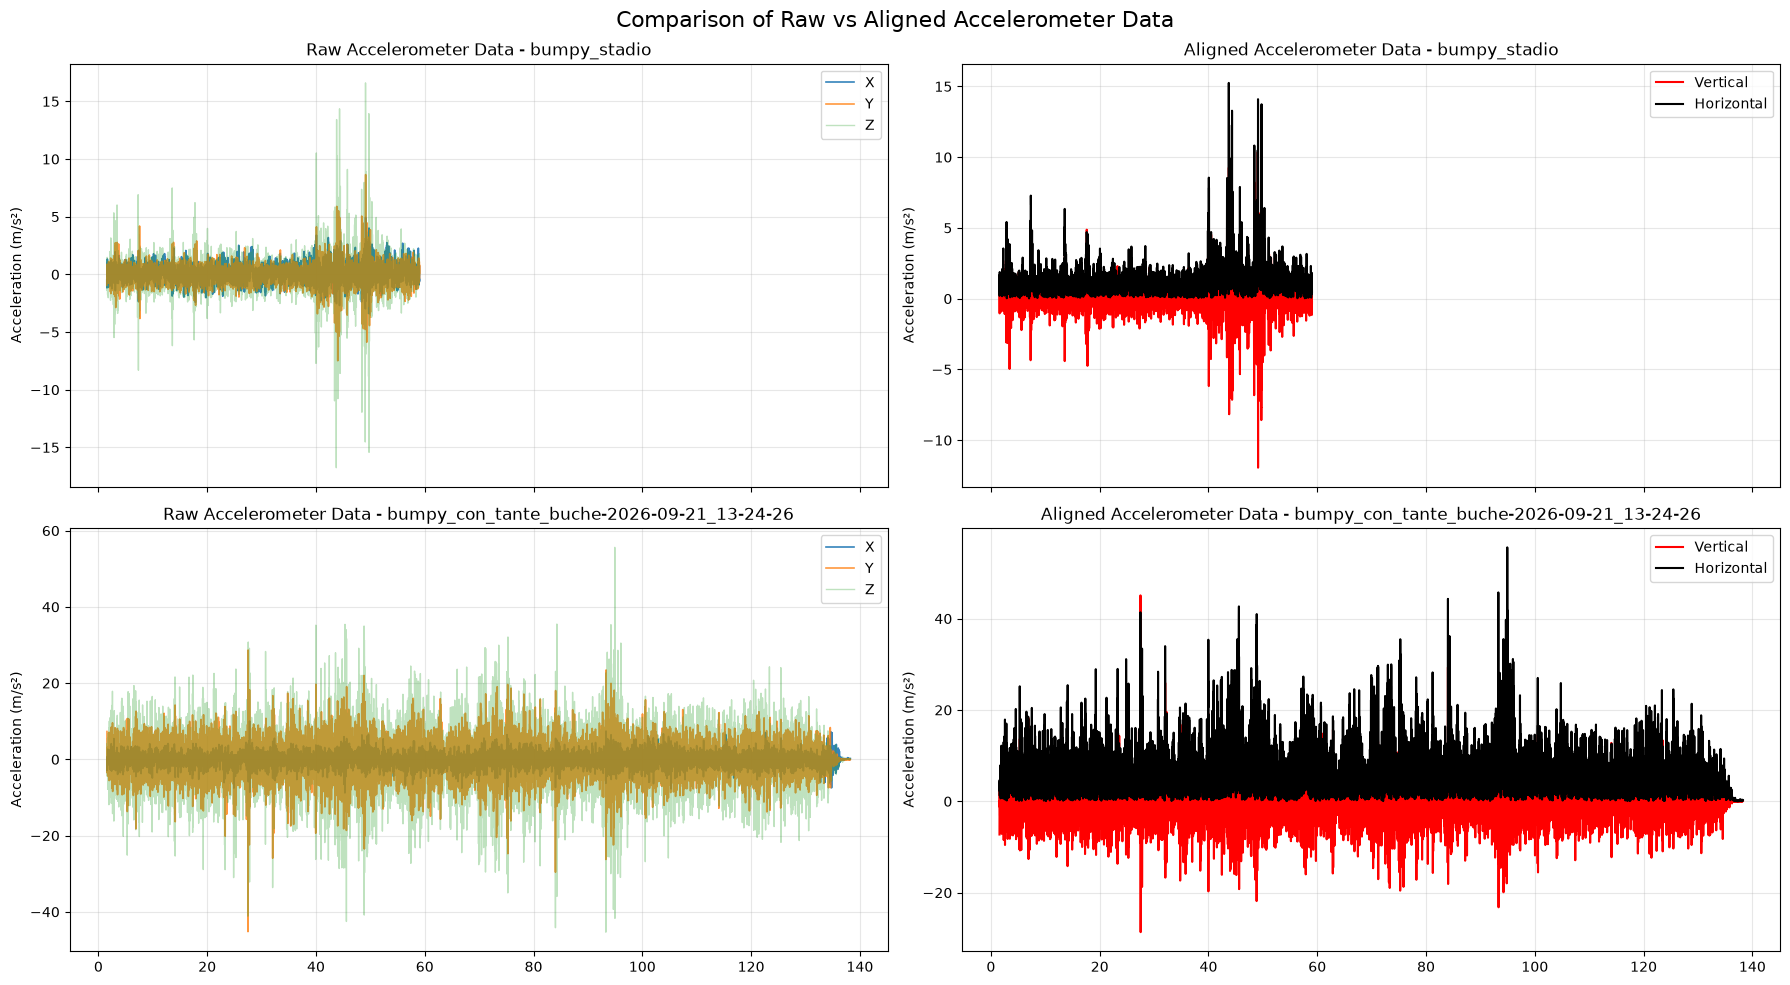

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Recording to compare
recording = ["bumpy_stadio", "bumpy_con_tante_buche-2026-09-21_13-24-26"]

# paths : INPUT_DIR_2 and OUTPUT_DIR_2

# create figure with 2 subplots: 2 recordings x 2 plots (raw vs aligned)
fig, axes = plt.subplots(len(recording), 2, figsize=(18, 10), sharex=True)

for idx, rec in enumerate(recording):
    # Load the raw and aligned accelerometer data
    raw_data = pd.read_csv(os.path.join(INPUT_DIR_2, rec, "Accelerometer.csv"))
    aligned_data = pd.read_csv(os.path.join(OUTPUT_DIR_2, rec, "Accelerometer_aligned.csv"))
    
    # Left column: Raw data
    ax_left = axes[idx, 0] if len(recording) > 1 else axes[0]
    ax_left.plot(raw_data['seconds_elapsed'], raw_data['x'], label='X', alpha=0.9, linewidth=1.2)
    ax_left.plot(raw_data['seconds_elapsed'], raw_data['y'], label='Y', alpha=0.8, linewidth=1.2)
    ax_left.plot(raw_data['seconds_elapsed'], raw_data['z'], label='Z', alpha=0.3, linewidth=1)
    ax_left.set_title(f'Raw Accelerometer Data - {rec}')
    ax_left.set_ylabel('Acceleration (m/s²)')
    ax_left.legend(loc='upper right')
    ax_left.grid(True, alpha=0.3)

    # Right column: Aligned data
    ax_right = axes[idx, 1] if len(recording) > 1 else axes[1]
    ax_right.plot(aligned_data['seconds_elapsed'], aligned_data['vertical'], label='Vertical', color='red')
    ax_right.plot(aligned_data['seconds_elapsed'], aligned_data['horizontal'], label='Horizontal', color='black')
    ax_right.set_title(f'Aligned Accelerometer Data - {rec}')
    ax_right.set_ylabel('Acceleration (m/s²)')
    ax_right.legend(loc='upper right')
    ax_right.grid(True, alpha=0.3)

plt.suptitle("Comparison of Raw vs Aligned Accelerometer Data", fontsize=16)
plt.tight_layout()
plt.show()

### Figure: Raw vs. Aligned Accelerometer Data

The plots above demonstrate the effectiveness of the gravity-based orientation alignment. 

*   **Left Column (Raw Data):** The raw X, Y, and Z axes are heavily dependent on the physical orientation of the smartphone during the recording. Comparing the two raw signals directly is misleading because the phone was mounted differently.
*   **Right Column (Aligned Data):** By projecting the 3D sensor data onto the mean gravity vector ($g\_hat$), we transform the measurements into a universal, orientation-independent coordinate system. 
    *   The **Vertical component (red)** successfully isolates the up/down forces. 
    *   The **Horizontal component (black)** captures the forward and lateral forces (e.g., pedaling, turning, and lateral vibrations), which are now cleanly separated from the vertical impacts.

This is actually good to separate the road bumps and irregularities from the rider movement, even if we must say that horizontal movement can be cause by holes and bumps also.


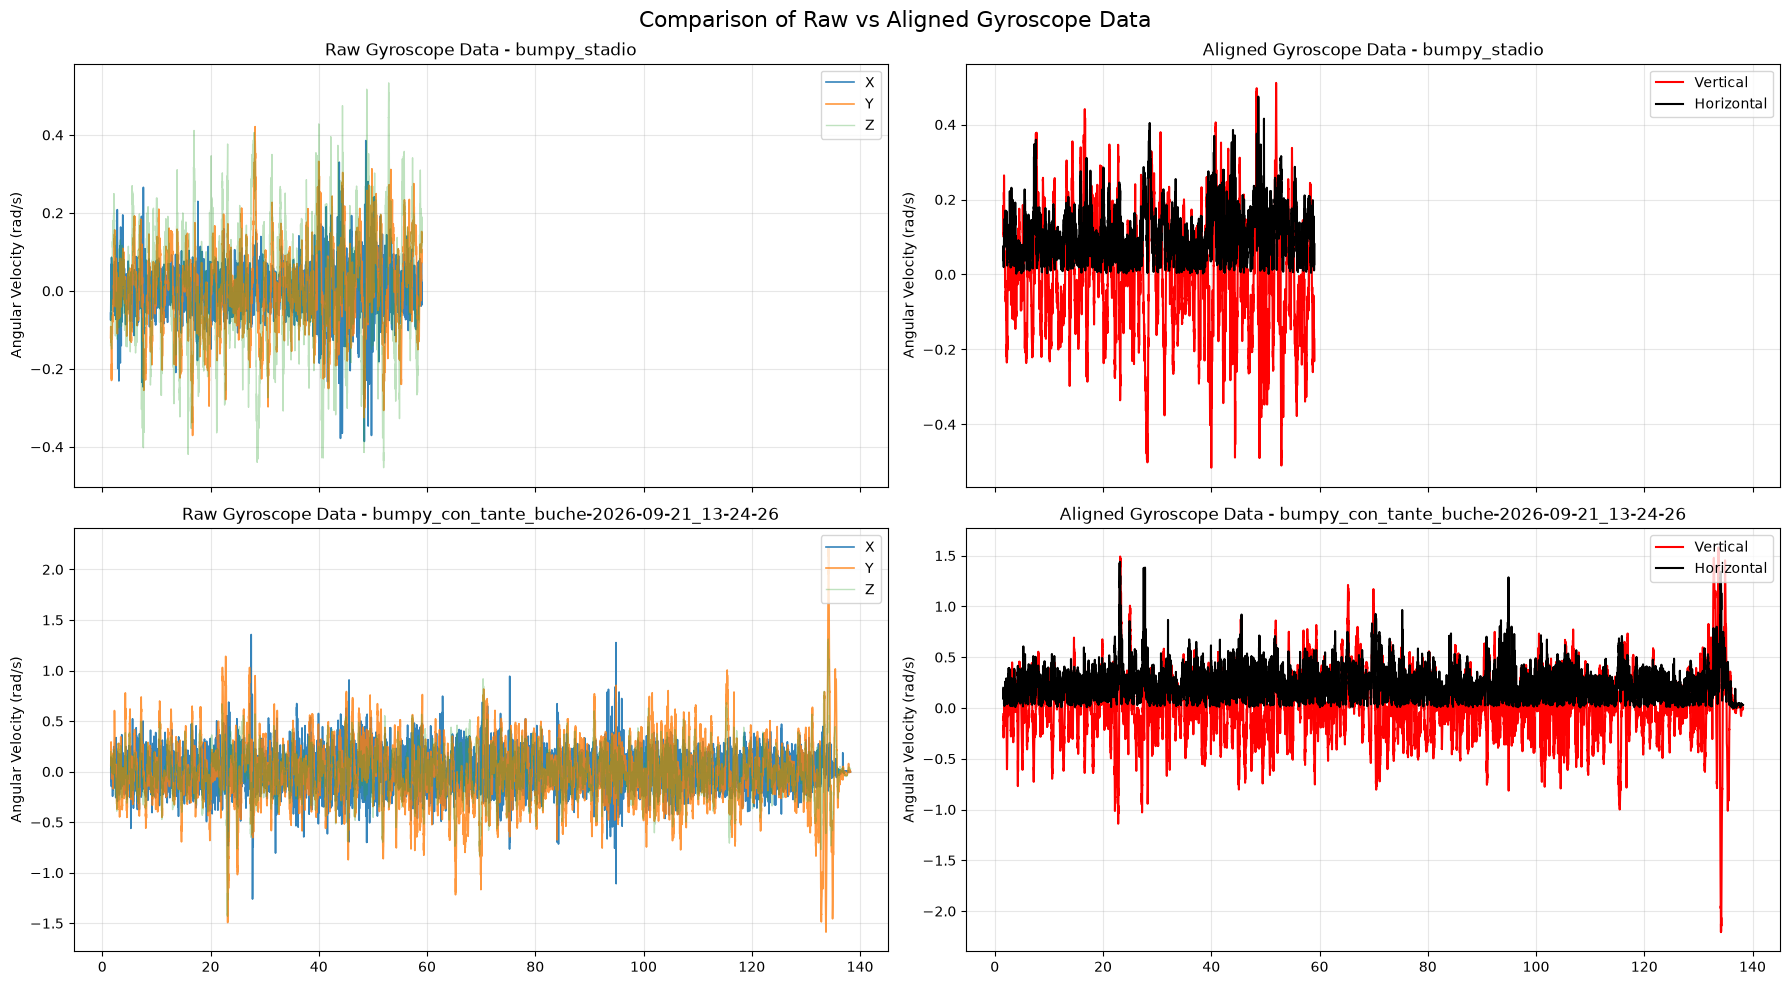

In [18]:
# gyroscope plotting script

import pandas as pd
import matplotlib.pyplot as plt
import os

# Recording to compare
recording = ["bumpy_stadio", "bumpy_con_tante_buche-2026-09-21_13-24-26"]

# paths : INPUT_DIR_2 and OUTPUT_DIR_2

# create figure with 2 subplots: 2 recordings x 2 plots (raw vs aligned)
fig, axes = plt.subplots(len(recording), 2, figsize=(18, 10), sharex=True)

for idx, rec in enumerate(recording):
    # Load the raw and aligned gyroscope data
    raw_data = pd.read_csv(os.path.join(INPUT_DIR_2, rec, "Gyroscope.csv"))
    aligned_data = pd.read_csv(os.path.join(OUTPUT_DIR_2, rec, "Gyroscope_aligned.csv"))
    
    # Left column: Raw data
    ax_left = axes[idx, 0] if len(recording) > 1 else axes[0]
    ax_left.plot(raw_data['seconds_elapsed'], raw_data['x'], label='X', alpha=0.9, linewidth=1.2)
    ax_left.plot(raw_data['seconds_elapsed'], raw_data['y'], label='Y', alpha=0.8, linewidth=1.2)
    ax_left.plot(raw_data['seconds_elapsed'], raw_data['z'], label='Z', alpha=0.3, linewidth=1)
    ax_left.set_title(f'Raw Gyroscope Data - {rec}')
    ax_left.set_ylabel('Angular Velocity (rad/s)')
    ax_left.legend(loc='upper right')
    ax_left.grid(True, alpha=0.3)

    # Right column: Aligned data
    ax_right = axes[idx, 1] if len(recording) > 1 else axes[1]
    ax_right.plot(aligned_data['seconds_elapsed'], aligned_data['vertical'], label='Vertical', color='red')
    ax_right.plot(aligned_data['seconds_elapsed'], aligned_data['horizontal'], label='Horizontal', color='black')
    ax_right.set_title(f'Aligned Gyroscope Data - {rec}')
    ax_right.set_ylabel('Angular Velocity (rad/s)')
    ax_right.legend(loc='upper right')
    ax_right.grid(True, alpha=0.3)

plt.suptitle("Comparison of Raw vs Aligned Gyroscope Data", fontsize=16)
plt.tight_layout()
plt.show()

# Exploratory FFT analysis

Before applying any filtering, it is essential to understand the **frequency characteristics** of our signals. By computing the FFT  for both smooth and bumpy road recordings, we ca for example:

1. **Identify Discriminative Frequency Bands**: We can visually and quantitatively compare which frequencies are present in bumpy roads but absent (or minimal) in smooth roads. This reveals the "spectral signature" of road roughness.

2. **Understand Noise Characteristics**: The FFT reveals high-frequency noise that should be removed, as well as low-frequency components (<1-2 Hz) related to pedaling or gravity residuals that are not relevant for bump detection.

3. **Avoid Signal Loss**: By examining the full spectrum first, we ensure we don't accidentally filter out the very frequencies that distinguish road conditions. This prevents us from discarding valuable information before feature extraction.

This will help us in designing a band pass filter later in the project

**PROBLEM** : Removing stationary segments creates time gaps. If you simply stitch the remaining data together, it creates artificial discontinuities (jumps). These jumps cause spectral leakage, introducing fake high-frequency noise that can ruin the design of your bandpass filter.

**Solution**: To get an accurate exploratory FFT, you must handle these gaps. You can either:
1. Calculate the FFT on each continuous segment separately and then average the results.
2. Simply use only the recordings that had no stationary segments removed for this specific exploratory step.

Since we don't have registrations with stationary parts for now i am going to simply do the second option, but for the band pass filter it's something that we will have to consider, since we don't want to consider this high-frequency noise.






Found 6 bumpy recordings and 9 smooth recordings.


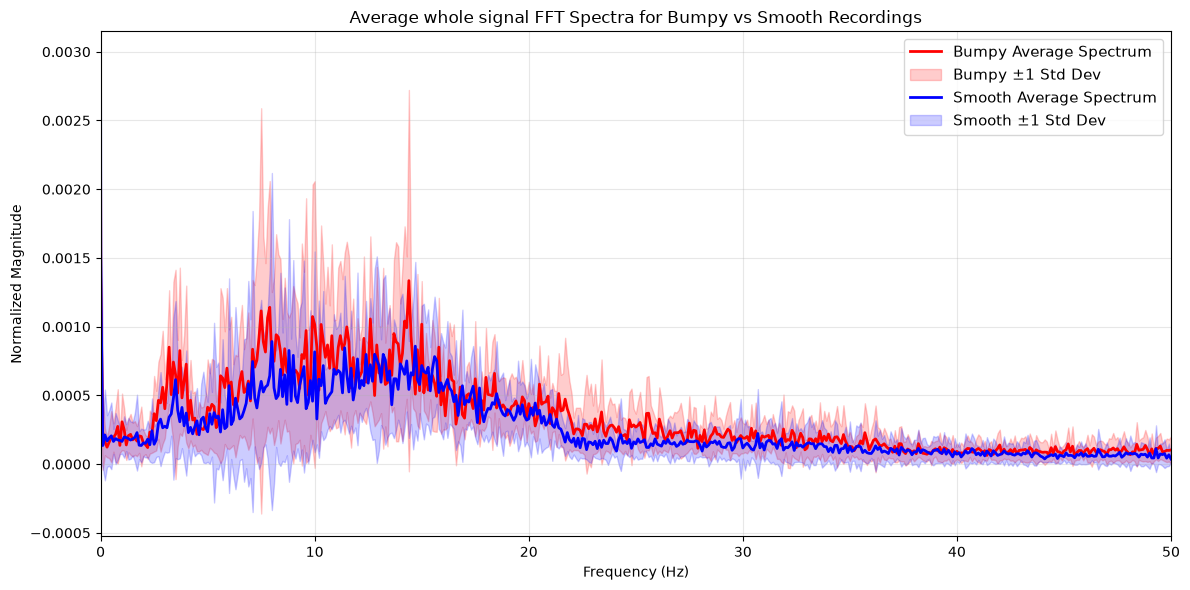

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import interpolate

# path: OUTPUT_DIR_2
fs = 100  # Sampling frequency in Hz

# keywords to separate recordings
BUMPY_KEYWORD = "bumpy"
SMOOTH_KEYWORD = "smooth"

all_recordings = os.listdir(OUTPUT_DIR_2)

bumpy_recordings = [rec for rec in all_recordings if BUMPY_KEYWORD in rec.lower()]
smooth_recordings = [rec for rec in all_recordings if SMOOTH_KEYWORD in rec.lower()]
unclassified_recordings = [rec for rec in all_recordings if BUMPY_KEYWORD not in rec.lower() and SMOOTH_KEYWORD not in rec.lower()]

if unclassified_recordings:
    print(f"Warning: Found {len(unclassified_recordings)} unclassified recordings: {unclassified_recordings}")

print(f"Found {len(bumpy_recordings)} bumpy recordings and {len(smooth_recordings)} smooth recordings.")

# Function to compute and interpolate whole signal fft
def compute_interpolated_fft(filepath, target_freqs):
    data = pd.read_csv(filepath)
    signal = data['vertical'].values
    n = len(signal)
    
    # Compute FFT
    fft_values = np.fft.rfft(signal)
    fft_freqs = np.fft.rfftfreq(n, 1/fs)
    magnitude = np.abs(fft_values)

    # Interpolate to target frequencies
    mask = fft_freqs <= fs/2  # Only consider frequencies up to Nyquist (implicitly done by rfft, but just to be safe)

    # Normalize so the spectrum sums to 1 (compare SHAPE, not absolute energy)
    magnitudes_normalized = magnitude / np.sum(magnitude)

    interp_func = interpolate.interp1d(fft_freqs[mask], magnitudes_normalized[mask], fill_value="extrapolate", bounds_error=False)
    return interp_func(target_freqs)


target_freqs = np.linspace(0, fs/2, 501)  # Interpolated frequency range

# we collect the interpolated spectra for bumpy and smooth recordings separately
bumpy_spectra = []
for rec in bumpy_recordings:
    filepath = os.path.join(OUTPUT_DIR_2, rec, "Accelerometer_aligned.csv")
    if os.path.exists(filepath):
        bumpy_spectra.append(compute_interpolated_fft(filepath, target_freqs))

smooth_spectra = []
for rec in smooth_recordings:
    filepath = os.path.join(OUTPUT_DIR_2, rec, "Accelerometer_aligned.csv")
    if os.path.exists(filepath):
        smooth_spectra.append(compute_interpolated_fft(filepath, target_freqs))

# we average the spectra for bumpy and smooth recordings
bumpy_avg_spectrum = np.mean(bumpy_spectra, axis=0) 
bumpy_std_spectrum = np.std(bumpy_spectra, axis=0)

smooth_avg_spectrum = np.mean(smooth_spectra, axis=0)
smooth_std_spectrum = np.std(smooth_spectra, axis=0)

# we plot the results

plt.figure(figsize=(12, 6))

# Plot bumpy spectrum with shaded std
plt.plot(target_freqs, bumpy_avg_spectrum, label='Bumpy Average Spectrum', color='red', linewidth=2)
plt.fill_between(target_freqs, bumpy_avg_spectrum - bumpy_std_spectrum, bumpy_avg_spectrum + bumpy_std_spectrum, color='red', alpha=0.2, label='Bumpy ±1 Std Dev')

# Plot smooth spectrum with shaded std
plt.plot(target_freqs, smooth_avg_spectrum, label='Smooth Average Spectrum', color='blue', linewidth=2)
plt.fill_between(target_freqs, smooth_avg_spectrum - smooth_std_spectrum, smooth_avg_spectrum + smooth_std_spectrum, color='blue', alpha=0.2, label='Smooth ±1 Std Dev')


plt.title('Average whole signal FFT Spectra for Bumpy vs Smooth Recordings')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Normalized Magnitude')
plt.xlim(0, 50)  
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### FFT Analysis Results

The average whole-signal FFT analysis reveals a spectral signature distinguishing bumpy from smooth roads:

- **Discriminative Frequency Band (5-20 Hz)**: Bumpy roads show  higher energy (this is more visible in the non-normalized figure below) in this range compared to smooth roads. This corresponds to the physical vibrations caused by road irregularities (potholes, cracks, uneven surfaces).

- **Low Frequencies (<5 Hz)**: Both road types show similar energy levels, likely corresponding to pedaling rhythm and general bike motion. These frequencies are not discriminative for road classification.

- **High Frequencies (>20 Hz)**: Energy converges to near-zero for both road types, indicating this range contains mostly sensor noise rather than meaningful signal.

- **Below, at~3 Hz, both curves rise sharply.** Possibly residual low-frequency drift, or an artifact of how we normalize 

**Filter Design Decision**: Based on this analysis, it would be useful to apply a **bandpass filter with cutoff frequencies at 4/5 Hz and 20/22 Hz**. This preserves the discriminative frequency band while removing non-informative low-frequency motion and high-frequency noise.

Now let's see the non-normalized version

Found 6 bumpy recordings and 9 smooth recordings.


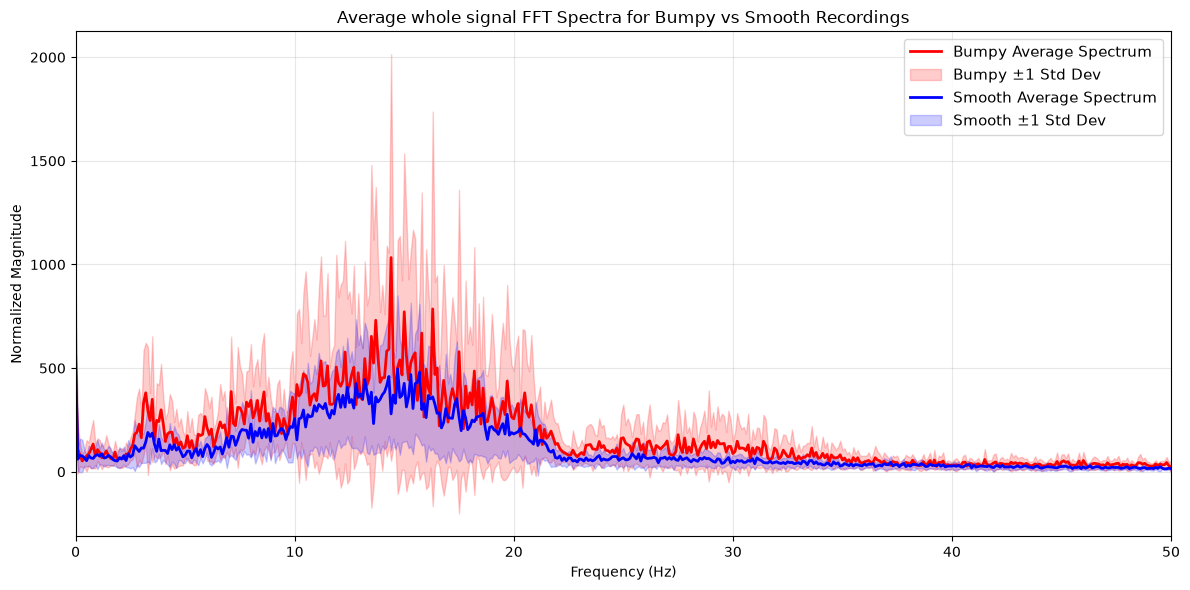

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import interpolate

# path: OUTPUT_DIR_2
fs = 100  # Sampling frequency in Hz

# keywords to separate recordings
BUMPY_KEYWORD = "bumpy"
SMOOTH_KEYWORD = "smooth"

all_recordings = os.listdir(OUTPUT_DIR_2)

bumpy_recordings = [rec for rec in all_recordings if BUMPY_KEYWORD in rec.lower()]
smooth_recordings = [rec for rec in all_recordings if SMOOTH_KEYWORD in rec.lower()]
unclassified_recordings = [rec for rec in all_recordings if BUMPY_KEYWORD not in rec.lower() and SMOOTH_KEYWORD not in rec.lower()]

if unclassified_recordings:
    print(f"Warning: Found {len(unclassified_recordings)} unclassified recordings: {unclassified_recordings}")

print(f"Found {len(bumpy_recordings)} bumpy recordings and {len(smooth_recordings)} smooth recordings.")

# Function to compute and interpolate whole signal fft
def compute_interpolated_fft(filepath, target_freqs):
    data = pd.read_csv(filepath)
    signal = data['vertical'].values
    n = len(signal)
    
    # Compute FFT
    fft_values = np.fft.rfft(signal)
    fft_freqs = np.fft.rfftfreq(n, 1/fs)
    magnitude = np.abs(fft_values)

    # Interpolate to target frequencies
    mask = fft_freqs <= fs/2  # Only consider frequencies up to Nyquist (implicitly done by rfft, but just to be safe)


    interp_func = interpolate.interp1d(fft_freqs[mask], magnitude[mask], fill_value="extrapolate", bounds_error=False)
    return interp_func(target_freqs)


target_freqs = np.linspace(0, fs/2, 501)  # Interpolated frequency range

# we collect the interpolated spectra for bumpy and smooth recordings separately
bumpy_spectra = []
for rec in bumpy_recordings:
    filepath = os.path.join(OUTPUT_DIR_2, rec, "Accelerometer_aligned.csv")
    if os.path.exists(filepath):
        bumpy_spectra.append(compute_interpolated_fft(filepath, target_freqs))

smooth_spectra = []
for rec in smooth_recordings:
    filepath = os.path.join(OUTPUT_DIR_2, rec, "Accelerometer_aligned.csv")
    if os.path.exists(filepath):
        smooth_spectra.append(compute_interpolated_fft(filepath, target_freqs))

# we average the spectra for bumpy and smooth recordings
bumpy_avg_spectrum = np.mean(bumpy_spectra, axis=0) 
bumpy_std_spectrum = np.std(bumpy_spectra, axis=0)

smooth_avg_spectrum = np.mean(smooth_spectra, axis=0)
smooth_std_spectrum = np.std(smooth_spectra, axis=0)

# we plot the results

plt.figure(figsize=(12, 6))

# Plot bumpy spectrum with shaded std
plt.plot(target_freqs, bumpy_avg_spectrum, label='Bumpy Average Spectrum', color='red', linewidth=2)
plt.fill_between(target_freqs, bumpy_avg_spectrum - bumpy_std_spectrum, bumpy_avg_spectrum + bumpy_std_spectrum, color='red', alpha=0.2, label='Bumpy ±1 Std Dev')

# Plot smooth spectrum with shaded std
plt.plot(target_freqs, smooth_avg_spectrum, label='Smooth Average Spectrum', color='blue', linewidth=2)
plt.fill_between(target_freqs, smooth_avg_spectrum - smooth_std_spectrum, smooth_avg_spectrum + smooth_std_spectrum, color='blue', alpha=0.2, label='Smooth ±1 Std Dev')


plt.title('Average whole signal FFT Spectra for Bumpy vs Smooth Recordings')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Normalized Magnitude')
plt.xlim(0, 50)  
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Reading the non-normalized FFT plot

**What changed vs the normalized version:** this shows absolute vibration energy, not just spectral shape.

- **Bumpy sits above smooth almost everywhere in the 2-22 Hz range**, not just at isolated peaks. This is expected: bumpy roads vibrate more overall (speed, impact intensity), so removing normalization brings back that general "louder" effect on top of any shape difference.
- **Same convergence above ~22 Hz** as the normalized plot — confirms this cutoff is real.
- **Peak region is broader here (~10-18 Hz)** rather than the two sharp separate peaks seen in the normalized version — the earlier 7/14 Hz harmonic pattern is harder to isolate visually against the overall elevated level.

## Takeaway

This version tells us bumpy roads carry more energy in general (useful for a time-domain feature like RMS/total energy) but is less useful than the normalized version for pinpointing *which* frequencies specifically discriminate the two classes — for that, keep using the normalized plot might be the best idea. Using both together is the best strategy.
In any case, we need more registrations.

## Sequence from this point onwards

1. Spectrogram →

2. Bandpass filter →

3. Windowing (with contextual label) → 

4. Feature extraction (RMS, energy, peaks, etc., per channel)
→ 
5. Correlation between features (Removal of redundant features with the covariance matrix for example)
→ 
6. Mutual information (only on the training fold) → Selection of predictive features
→
7. Normalization (fit only on the training fold)
→
8. Classifier (GroupKFold, baseline, metrics per class)
	​


## Spectrogram

While the global FFT provided the average frequency content to design our bandpass filter, it loses all temporal information. We compute the spectrogram (Short-Time Fourier Transform) to observe how the frequency content evolves over time.


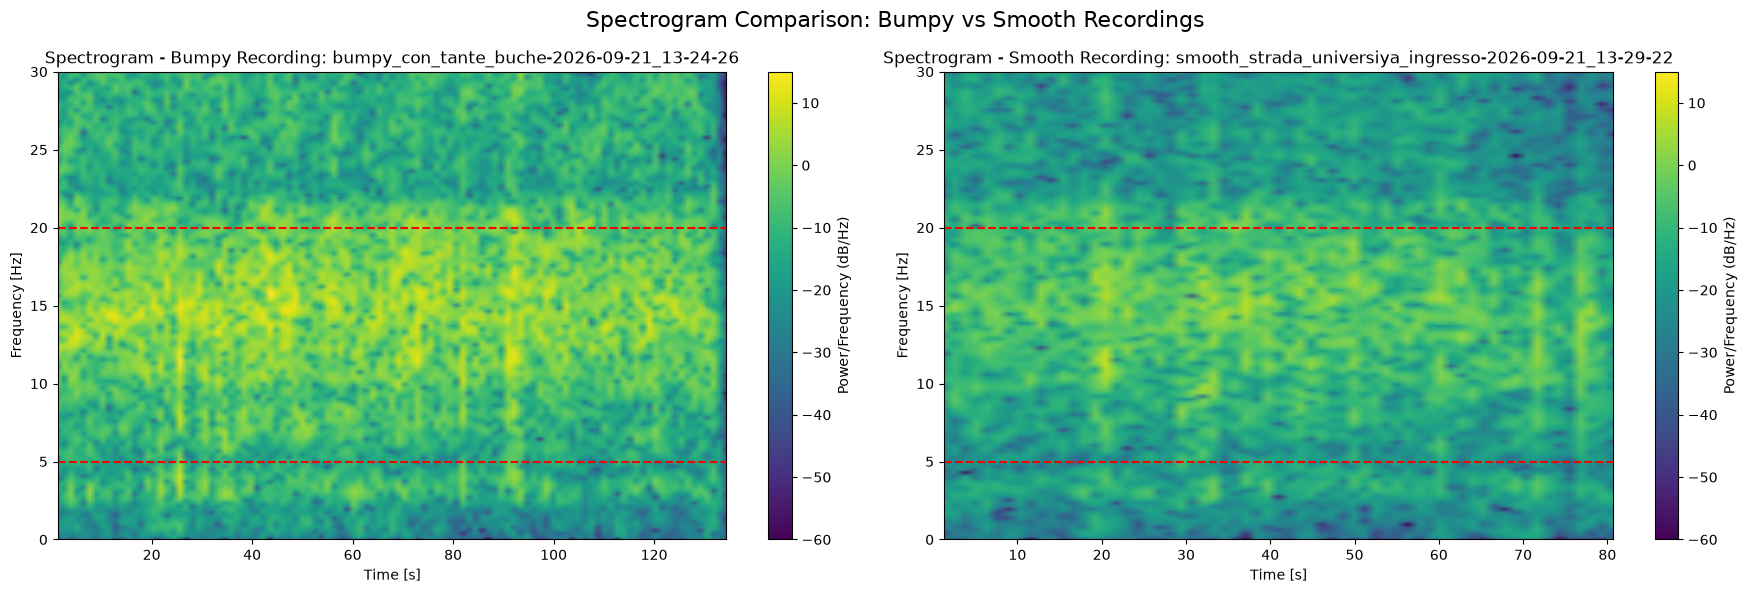

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import os

# path: OUTPUT_DIR_2

# pick one bumpy and one smooth recording for comparison
BUMPY_RECORDING = "bumpy_con_tante_buche-2026-09-21_13-24-26"
SMOOTH_RECORDING = "smooth_strada_universiya_ingresso-2026-09-21_13-29-22"

fs = 100  # Sampling frequency in Hz

#load data
bumpy_data = pd.read_csv(os.path.join(OUTPUT_DIR_2, BUMPY_RECORDING, "Accelerometer_aligned.csv"))
smooth_data = pd.read_csv(os.path.join(OUTPUT_DIR_2, SMOOTH_RECORDING, "Accelerometer_aligned.csv"))

#extract vertical signals
bumpy_vertical = bumpy_data['vertical'].values
smooth_vertical = smooth_data['vertical'].values
time_bumpy = bumpy_data['seconds_elapsed'].values
time_smooth = smooth_data['seconds_elapsed'].values

# Compute the spectrograms
nperseg = 256  # Length of each segment for the spectrogram
noverlap = nperseg // 2  # Overlap between segments
nfft = 512  # Number of FFT points

# compute spectrogram for bumpy recording
f_bumpy, t_bumpy, Sxx_bumpy = signal.spectrogram(bumpy_vertical, fs=fs, nperseg=nperseg, noverlap=noverlap, nfft=nfft, scaling='density', window='hann')

# compute spectrogram for smooth recording
f_smooth, t_smooth, Sxx_smooth = signal.spectrogram(smooth_vertical, fs=fs, nperseg=nperseg, noverlap=noverlap, nfft=nfft, scaling='density', window='hann')

# plot spectograms side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bumpy spectrogram
im1 = axes[0].pcolormesh(t_bumpy, f_bumpy, 10 * np.log10(Sxx_bumpy), shading='gouraud', cmap='viridis',  vmin=-60, vmax=15)
axes[0].set_title(f'Spectrogram - Bumpy Recording: {BUMPY_RECORDING}')
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylim(0, 30)  # Limit frequency axis to 30 Hz
axes[0].axhline(y=5, color='red', linestyle='--')
axes[0].axhline(y=20, color='red', linestyle='--')
plt.colorbar(im1, ax=axes[0], label='Power/Frequency (dB/Hz)')

# Smooth spectrogram
im2 = axes[1].pcolormesh(t_smooth, f_smooth, 10 * np.log10(Sxx_smooth), shading='gouraud', cmap='viridis', vmin=-60, vmax=15)
axes[1].set_title(f'Spectrogram - Smooth Recording: {SMOOTH_RECORDING}')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylim(0, 30)  # Limit frequency axis to 30 Hz
axes[1].axhline(y=5, color='red', linestyle='--')
axes[1].axhline(y=20, color='red', linestyle='--')
plt.colorbar(im2, ax=axes[1], label='Power/Frequency (dB/Hz)')

plt.suptitle('Spectrogram Comparison: Bumpy vs Smooth Recordings', fontsize=16)
plt.tight_layout()
plt.show()

# Insight from this figure

* **Genuine Intensity Difference:** The consistent color scale confirms the higher energy in the 5-20 Hz band for bumpy roads in comparison to smooth roads.
* **Intensity vs. Presence:** Both road types exhibit a baseline vibration in the 5-20 Hz range (likely from pedaling, rolling friction, and frame resonance). Therefore, the **magnitude** of the vibration is the true discriminative feature for our model.
*   **Sustained Roughness vs. Discrete Impacts:** The bumpy spectrogram shows a continuous elevated band rather than isolated vertical streaks. This suggests the recording captures sustained surface roughness rather than isolated potholes. (We have to coonfirm this using a registration with many individual potholes)
*   **Validation of Filter Cutoffs:** Both recordings remain consistently quiet below ~5 Hz and above ~20/22 Hz across the entire time axis. This provides strong confirmation for the design of our band pass filter.
